In [93]:
import pandas as pd

In [94]:
import numpy as np

In [95]:
import matplotlib.pyplot as plt

In [96]:
import seaborn as sns

In [97]:
import plotly.express as px

In [98]:
import plotly.graph_objects as go

In [99]:
from PIL import Image

In [100]:
from IPython.display import Image

In [101]:
from wordcloud import WordCloud,STOPWORDS

In [102]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [103]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Salary_Dataset.script.xlsx.csv')

In [104]:
df.head(10)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
5,4.2,Freelancer,Android Developer,100000,3,Bangalore,Full Time,Android
6,3.7,SQUARE N CUBE,Android Developer,192000,3,Bangalore,Full Time,Android
7,3.1,Samsung R&D Institute India - Bangalore,Android Developer,400000,3,Bangalore,Full Time,Android
8,3.7,DXMinds Technologies,Android Developer,300000,3,Bangalore,Full Time,Android
9,3.6,Endeavour Software Technologies,Android Developer,600000,3,Bangalore,Full Time,Android


In [105]:
df.tail(10)

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
22760,4.0,DiscoverWeb,Web Developer,100000,1,Bangalore,Full Time,Web
22761,4.6,Masai School,Web Developer,101376,1,Bangalore,Full Time,Web
22762,3.9,Fresher Zones,Web Developer,100000,1,Bangalore,Full Time,Web
22763,4.4,Unicon Systems,Web Developer,500000,1,Bangalore,Full Time,Web
22764,5.0,BJSHub,Web Developer,400000,1,Bangalore,Full Time,Web
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web
22769,3.8,Thomson Reuters,Associate Web Developer,300000,7,Bangalore,Full Time,Web


In [106]:
df.info()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


np.int64(0)

In [107]:
df.nunique()

,0
Rating,41
Company Name,11260
Job Title,1080
Salary,316
Salaries Reported,82
Location,10
Employment Status,4
Job Roles,11


In [108]:
print("Highest Salary:",round(df["Salary"].max()))
print("Lowest Salary:",round(df["Salary"].min()))
print("Average Salary:",round(df["Salary"].mean()))
print("Median Salary:",round(df["Salary"].mean()))
print("Mode Salary:",round(df["Salary"].mode()[0]))

Highest Salary: 90000000
Lowest Salary: 2112
Average Salary: 695387
Median Salary: 695387
Mode Salary: 300000


LOCATION WISE SALARY

/tmp/ipython-input-2869619213.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Salary', ylabel='Location'>

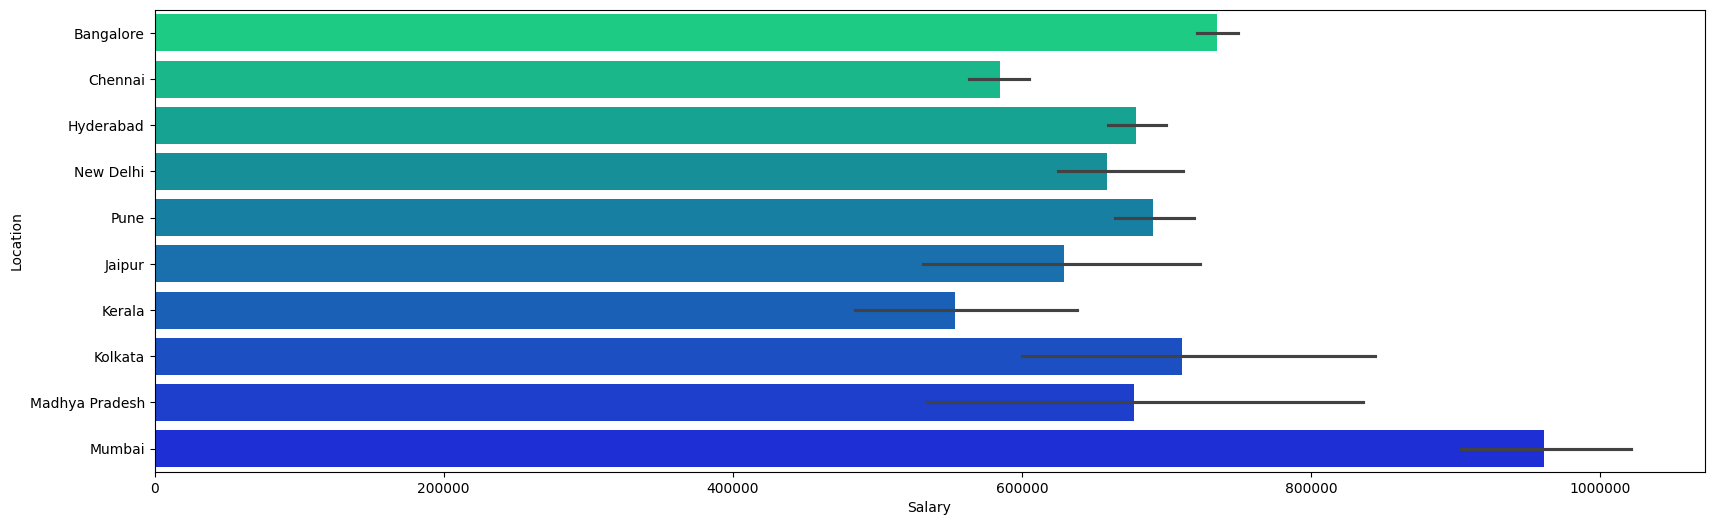

In [109]:
plt.figure(figsize=(20,6))
plt.ticklabel_format(style='plain')
sns.barplot(x=df["Salary"],y=df["Location"],palette="winter_r")

COMPANY SALARIES


/tmp/ipython-input-2338604620.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




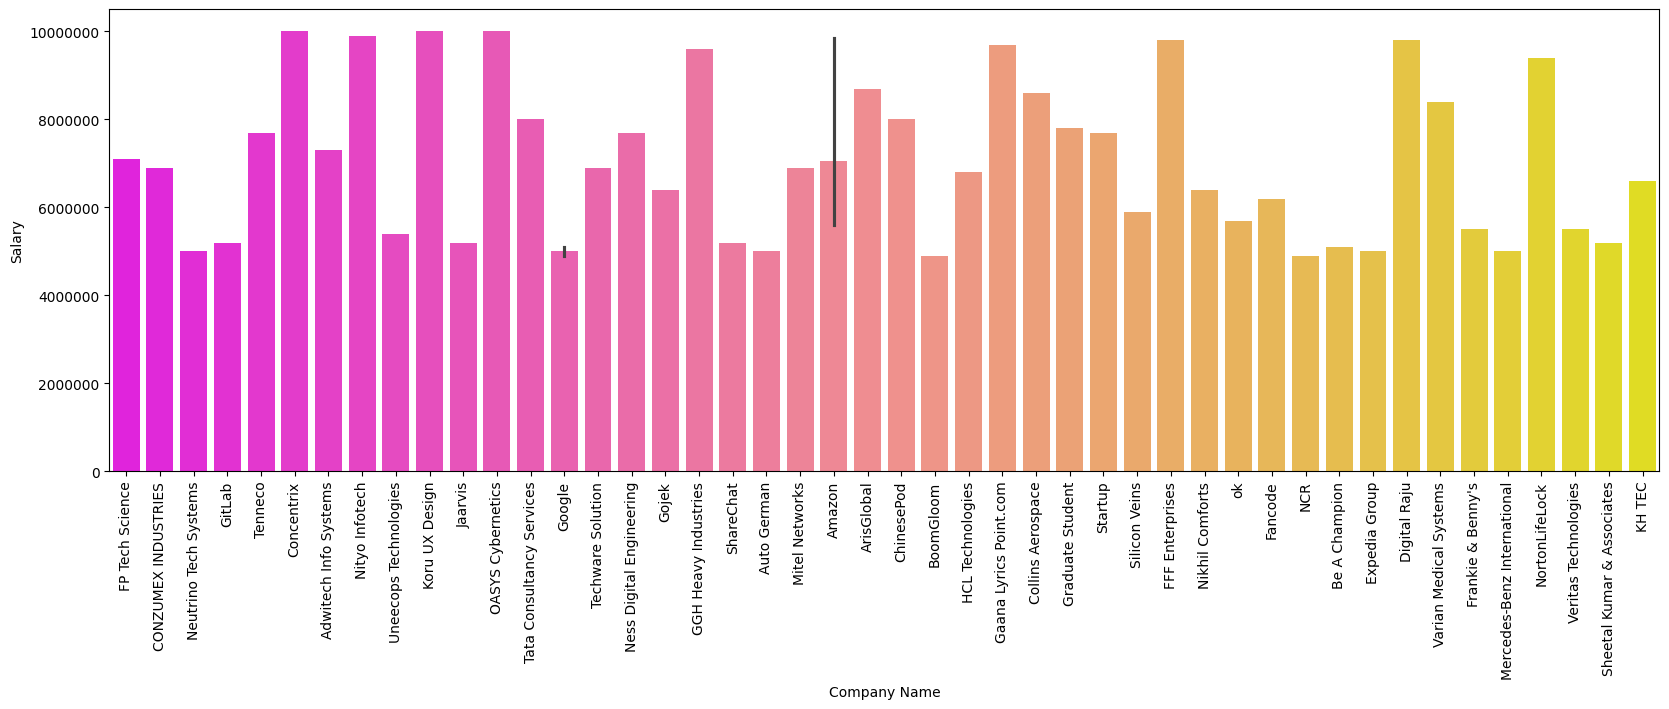

In [110]:
plt.figure(figsize=(20,6))
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain')
df.sort_values("Salary",axis=0,ascending=False,inplace=True)
sns.barplot(x=df["Company Name"][1:50],y=df["Salary"][1:51],palette="spring");

WORD CLOUD ON DIFFERENT COMPANY NAMES

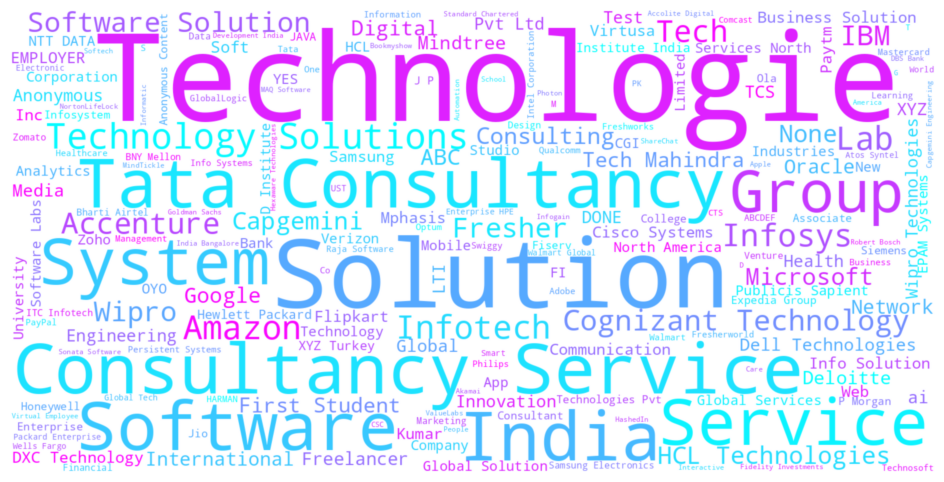

In [111]:
text=" ".join(str(Company) for Company in df["Company Name"])
word_cloud=WordCloud(width=1600,height=800,colormap='cool',background_color="white").generate(text)
plt.figure(figsize=(30,6))
plt.imshow(word_cloud,interpolation="gaussian")
plt.axis("off")
plt.show()

DIFFERENT JOB TITLES?

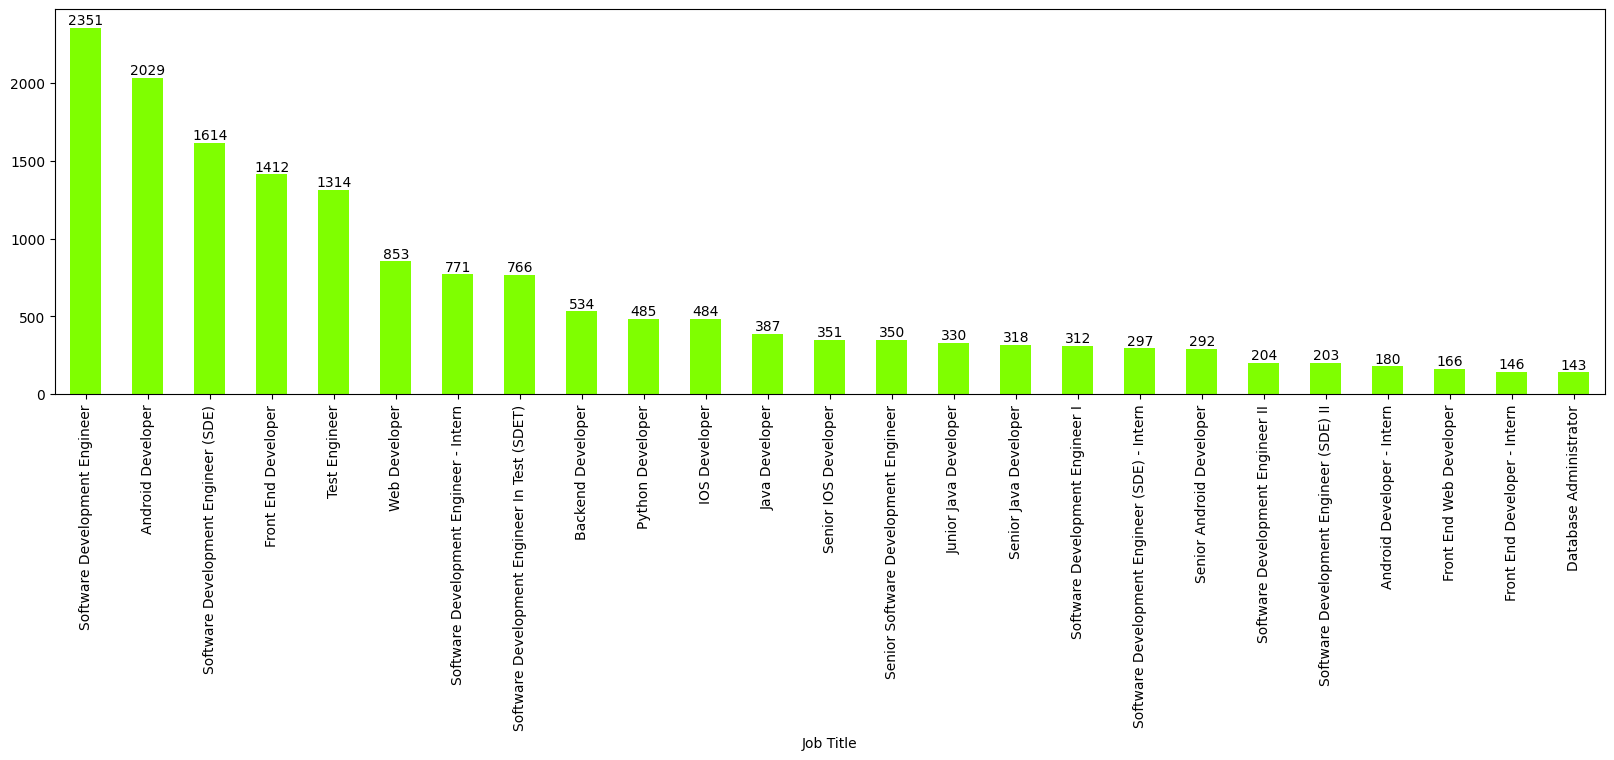

In [112]:
plt.figure(figsize=(20,5))
ax=df["Job Title"].value_counts()[:25].plot(kind='bar',color="chartreuse")
for p in ax.patches:
  ax.annotate(int(p.get_height()), (p.get_x()+0.25, p.get_height()+1), ha='center', va='bottom', color='black')

5 TOP JOB TITLES??

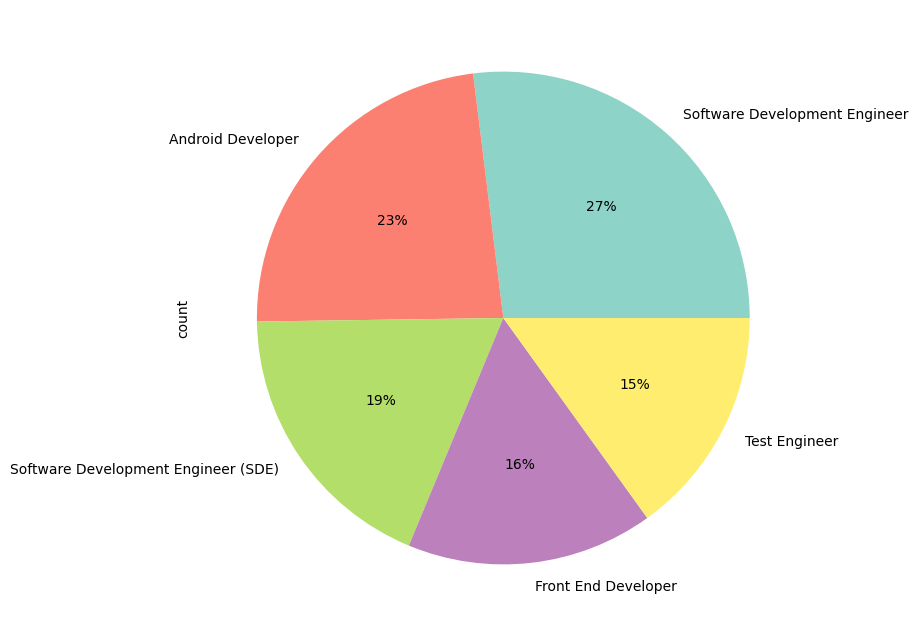

In [113]:
plt.figure(figsize=(10,8))
df['Job Title'].value_counts().head(5).plot(kind='pie',autopct='%.0f%%',colormap="Set3")
plt.show()

SALARY DISTRIBUTION??

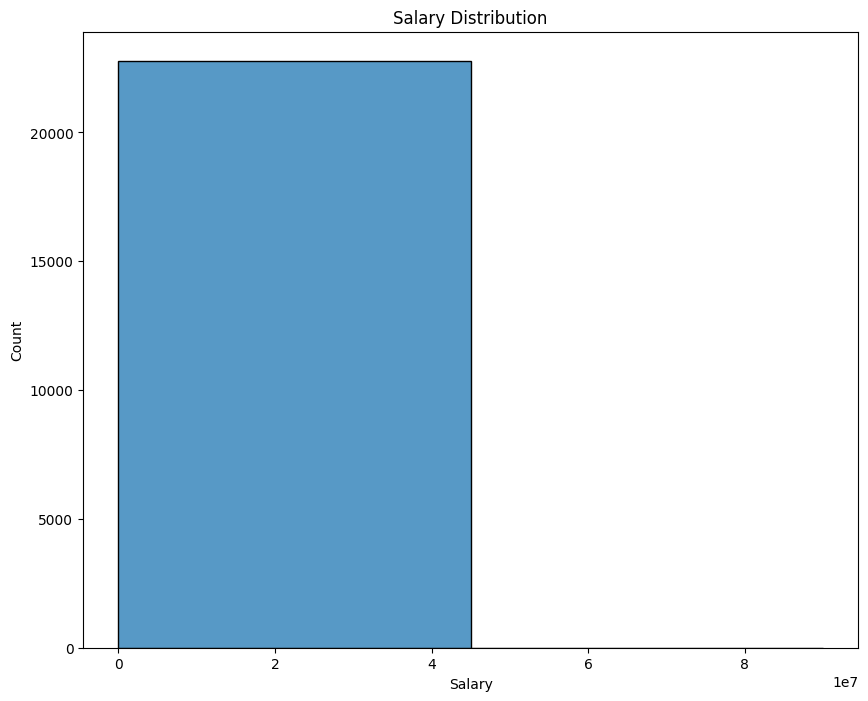

In [114]:
plt.figure(figsize=(10,8))
plt.title('Salary Distribution')
sns.histplot(df['Salary'],bins=2)
plt.show()

In [115]:
df["Job Roles"].value_counts(50)

,proportion
Job Roles,
SDE,0.359376
Android,0.129337
Frontend,0.094993
Java,0.081599
Testing,0.076416
IOS,0.071629
Backend,0.052437
Web,0.043874
Python,0.041590


DIFFERENT JOB ROLES??

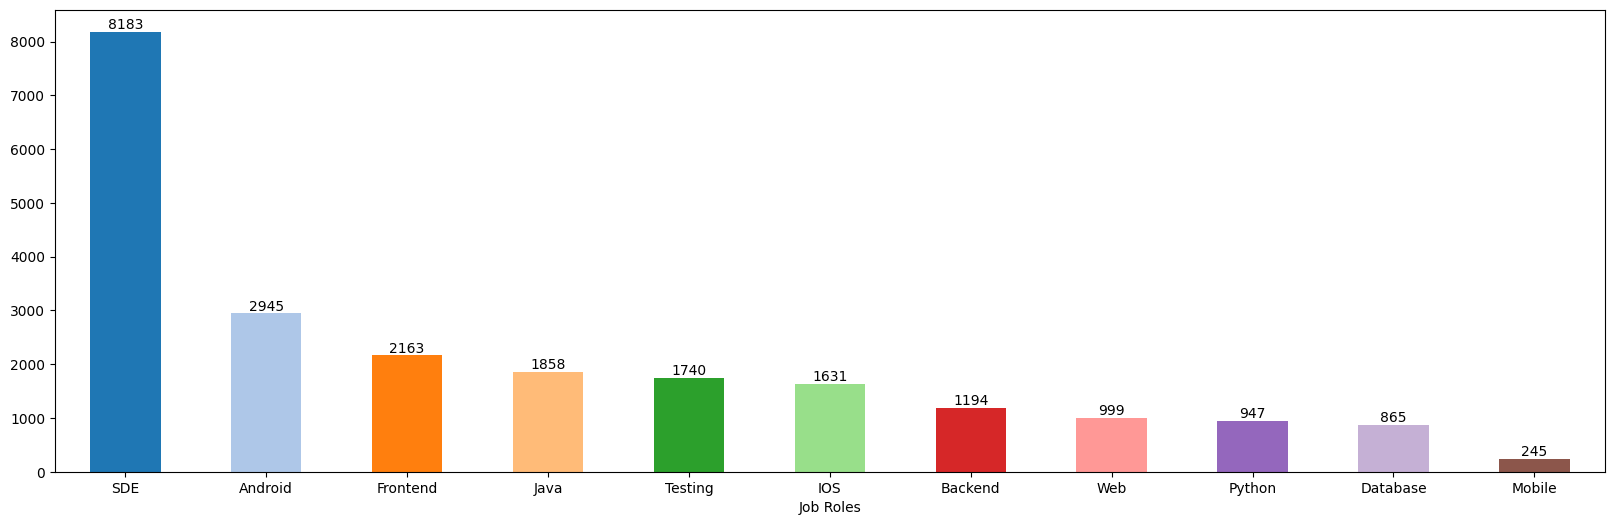

In [116]:
plt.figure(figsize=(20,6))
col_map=plt.colormaps['tab20']
ax=df["Job Roles"].value_counts().plot(kind='bar',color=col_map.colors,rot=0,linewidth=2.5)
for p in ax.patches:
  ax.annotate(int(p.get_height()),(p.get_x()+0.25,p.get_height()+1),ha='center',va='bottom',color='black')

SALARY PROVIDED TO DIFFERENT JOBS??


/tmp/ipython-input-3820046801.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Job Roles', ylabel='Salary'>

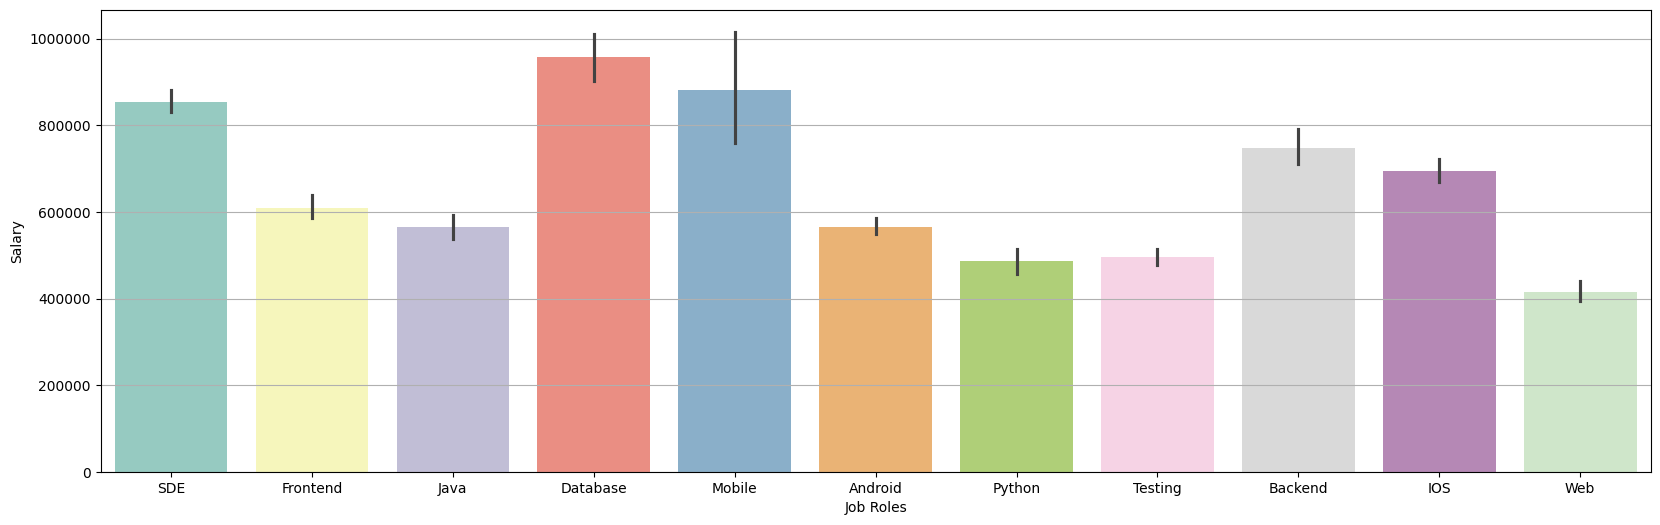

In [117]:
plt.figure(figsize=(20,6))
plt.grid()
plt.ticklabel_format(style='plain')
df.sort_values("Salary",axis=0,ascending=False,inplace=True)
sns.barplot(x=df["Job Roles"],y=df["Salary"],palette="Set3")

LE'S SEE THE COMPANY RATING DISTRIPUTION GIVENBY EMPLOYEES??

/tmp/ipython-input-1225264464.py:3: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



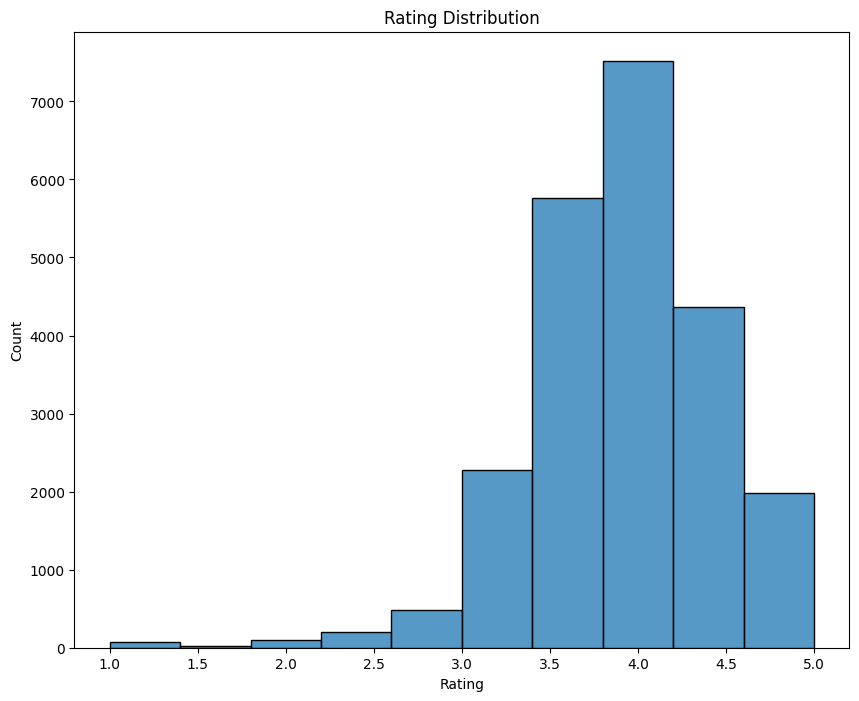

In [118]:
plt.figure(figsize=(10,8))
plt.title('Rating Distribution')
sns.histplot(df.Rating,palette="colors",bins=10)
plt.show()